# Phase 2: Tracing the "Capital City" Circuit

Phase 1 ended with an observation: on `"The capital of Germany is Berlin. The capital of France is"`, GPT-2 Small has no idea until layer 8 and is certain by layer 9. Ablation pointed at one head, L9H8.

**Goal:** turn that observation into a mechanism. Which components produce the answer, how much does each contribute, and what is L9H8 actually doing?

The tool is **direct logit attribution (DLA)**: because every component *adds* to the residual stream, the final logit difference is a *sum* of per-component terms, and we can read each term off directly.

> **Revision note (Sep 2026).** The first version of this notebook reported attributions like "L9H8 contributes +33.7" while the actual Paris logit was 13.4, and captioned the discrepancy "a small gap due to LayerNorm". The decomposition summed to 187. The missing piece was the final LayerNorm's *scale*, which divides every component by the same factor (about 14× here); the metric was also a raw logit rather than a difference, so LayerNorm's mean-subtraction did not cancel either. Section 1 does the accounting exactly, to three decimals, and explains each term.

## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(""))          # experiments/ on the path
sys.path.insert(0, os.path.abspath("experiments"))  # when run from repo root
import warnings; warnings.filterwarnings("ignore")
import logging; logging.getLogger().setLevel(logging.ERROR)
import torch, numpy as np, pandas as pd
import plotly.express as px, plotly.graph_objects as go, plotly.io as pio
from plotly.subplots import make_subplots
pio.renderers.default = "png"          # static images: render on GitHub, no JS needed
pio.templates.default = "plotly_white"
from interp_utils import *
print(f"device={DEVICE}")

device=mps


In [2]:
model = load_gpt2()
paris, rome = answer_ids(model)
tokens = model.to_tokens(CLEAN_PROMPT)
str_toks = model.to_str_tokens(tokens[0])
logits, cache = model.run_with_cache(tokens)
probs = logits[0, -1].softmax(-1)
LD = logit_diff(logits, paris, rome).item()
print("tokens:", str_toks)
print(f"P(Paris)={probs[paris]:.3f}  P(Rome)={probs[rome]:.3f}  logit diff Paris−Rome = {LD:.3f}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2-small into HookedTransformer
tokens: ['<|endoftext|>', 'The', ' capital', ' of', ' Germany', ' is', ' Berlin', '.', ' The', ' capital', ' of', ' France', ' is']
P(Paris)=0.703  P(Rome)=0.002  logit diff Paris−Rome = 6.045


## 1. Direct logit attribution, done exactly

The final residual stream at the answer position is a sum:

$$x_{\text{final}} = \text{embed} + \text{pos} + \sum_{\text{heads}} h_i + \sum_{\text{MLPs}} m_j$$

The logits are $\text{LN}(x_{\text{final}})\,W_U + b_U$. LayerNorm is $\frac{x - \mu(x)}{\sigma(x)} \cdot \gamma + \beta$. Two things make this hard to decompose and one trick makes it easy:

- $\sigma(x)$ is computed on the *sum*, so it is a single number per token. Divide every component by that same cached scale and the decomposition is linear again. TransformerLens caches it as `ln_final.hook_scale` and `cache.apply_ln_to_stack` applies it.
- $\mu(x)$ subtracts the same scalar from every dimension. For a single logit that leaks in through $W_U$; for a **logit difference** $W_U[:,a] - W_U[:,b]$ it cancels (TransformerLens additionally centers $W_U$ so it cancels for single logits too).
- $\gamma$ and $\beta$ are folded into $W_U$ and $b_U$ at load time, so the only leftover is $b_U[a] - b_U[b]$, a constant.

So: **project each component through the cached LayerNorm scale onto the direction $W_U[:,\text{Paris}] - W_U[:,\text{Rome}]$, add the bias term, and the sum must equal the observed logit difference.** Let's check.

In [3]:
direction = logit_diff_direction(model)                 # W_U[:, Paris] - W_U[:, Rome]
bias_term = (model.b_U[paris] - model.b_U[rome]).item()   # folded ln_final bias

layer_contrib, layer_labels = per_layer_dla(model, cache, direction)   # embed, pos_embed, L0 attn, L0 mlp, ...
head_contrib, head_labels = per_head_dla(model, cache, direction)       # [12, 12]

print(f"sum of component terms : {layer_contrib.sum():.3f}")
print(f"+ unembed bias term    : {bias_term:+.3f}")
print(f"= {layer_contrib.sum() + bias_term:.3f}   vs observed logit diff {LD:.3f}")

sum of component terms : 5.319
+ unembed bias term    : +0.726
= 6.045   vs observed logit diff 6.045


Exact. Everything below is a slice of that sum, so the numbers are in **logits of Paris-over-Rome** and can be compared to each other and to the total (about 6).

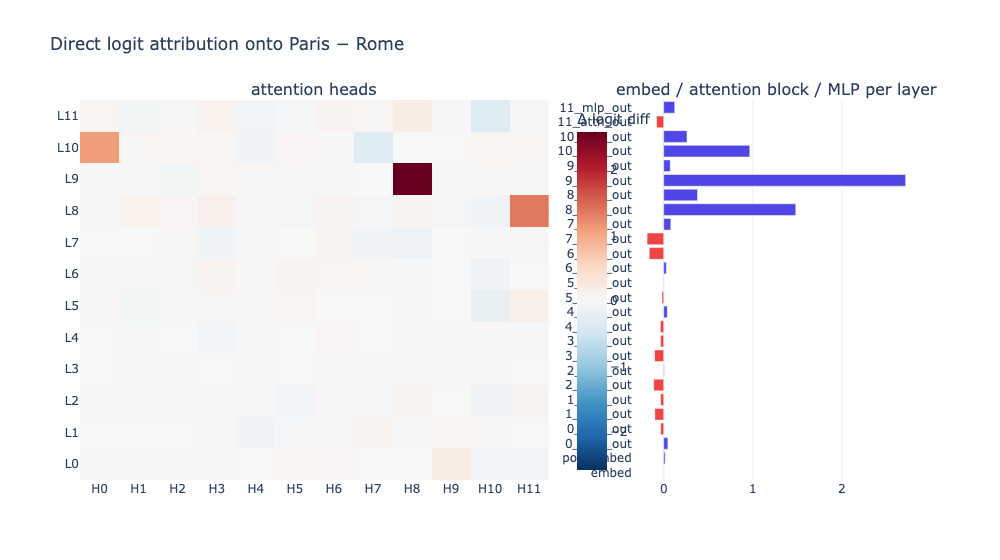

top heads:
  L9H8    +2.58
  L8H11   +1.37
  L10H0   +1.09
  L11H10  -0.36
  L10H7   -0.35
  L5H10   -0.20
  L0H9    +0.20
  L11H8   +0.19

layers:
  8_attn_out   +1.48
  8_mlp_out    +0.38
  9_attn_out   +2.72
  10_attn_out  +0.97


In [4]:
fig = make_subplots(rows=1, cols=2, column_widths=[0.62, 0.38], subplot_titles=["attention heads", "embed / attention block / MLP per layer"])
fig.add_heatmap(z=head_contrib.numpy(), x=[f"H{h}" for h in range(12)], y=[f"L{l}" for l in range(12)],
                colorscale="RdBu_r", zmid=0, colorbar=dict(title="Δ logit diff", x=0.58), row=1, col=1)
fig.add_bar(x=layer_contrib.numpy(), y=layer_labels, orientation="h", showlegend=False,
            marker_color=["#4f46e5" if v > 0 else "#ef4444" for v in layer_contrib], row=1, col=2)
fig.update_layout(width=1000, height=560, title="Direct logit attribution onto Paris − Rome")
fig.show()

ranked = sorted([(f"L{l}H{h}", head_contrib[l, h].item()) for l in range(12) for h in range(12)], key=lambda x: -abs(x[1]))
print("top heads:")
for n, v in ranked[:8]:
    print(f"  {n:7s} {v:+.2f}")
print("\nlayers:")
for n, v in zip(layer_labels, layer_contrib):
    if abs(v) > 0.3: print(f"  {n:12s} {v:+.2f}")

Three attention heads do most of the work: **L9H8** (+2.6, about 40% of the total on its own), **L8H11** (+1.4) and **L10H0** (+1.1). Two heads push back, **L10H7** and **L11H10**. The MLPs are close to neutral *on this metric*: they matter for making " Paris" likely in absolute terms, but they do not distinguish Paris from Rome much. That division of labor (attention heads move the country identity into the answer position, MLPs sharpen whatever arrives) is why a logit difference is the right lens for a *routing* question.

Compare with the old, unscaled numbers: the ranking of the top head was right, but the supporting cast was wrong (MLPs 8 to 11 looked like the second-biggest contributors because a raw Paris logit rewards anything that makes "a city" more likely), and every number was inflated 14×.

## 2. The star: L9H8

Where does it look (QK), and what does it write (OV)?

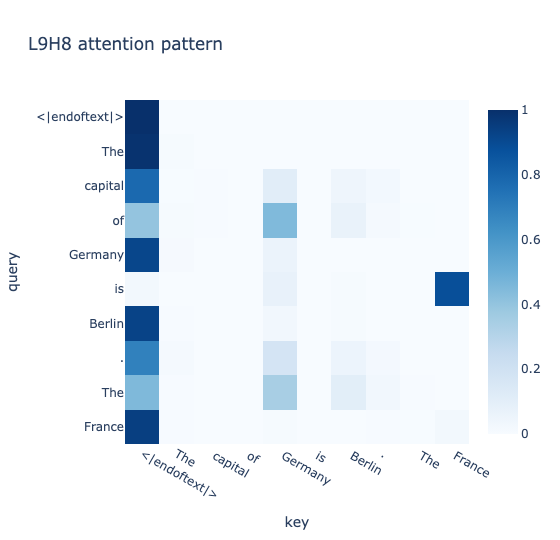

from the final token, L9H8 attends to:
  '<|endoftext|>' 0.02
  ' Germany'     0.08
  ' France'      0.88


In [5]:
pat = cache["blocks.9.attn.hook_pattern"][0, 8]
fig = px.imshow(pat.cpu().numpy(), x=str_toks, y=str_toks, color_continuous_scale="Blues", zmin=0, zmax=1,
                title="L9H8 attention pattern", labels=dict(x="key", y="query"))
fig.update_layout(width=560, height=540); fig.show()
print("from the final token, L9H8 attends to:")
for t, w in zip(str_toks, pat[-1]):
    if w > 0.02: print(f"  {t!r:14s} {w:.2f}")

In [6]:
# OV circuit: take the residual stream at the ' France' position (input to layer 9), push it through
# this head's W_V @ W_O, and ask which vocabulary directions the result points at.
france_pos = str_toks.index(" France")
W_V, W_O = model.W_V[9, 8], model.W_O[9, 8]
resid_in = cache["blocks.9.ln1.hook_normalized"][0, france_pos]     # what the head actually reads (post-LN)
written = resid_in @ W_V @ W_O                                      # [d_model]
scores = written @ model.W_U                                        # project onto every token's unembedding
top = scores.topk(15)
print("if L9H8 attended fully to ' France', its output would promote:")
for v, i in zip(top.values, top.indices):
    print(f"  {model.to_string(i.item())!r:14s} {v:+.2f}")
print(f"\nrank of ' Paris' among all tokens: {rank_of(scores, paris)};  ' Rome': {rank_of(scores, rome)}")

if L9H8 attended fully to ' France', its output would promote:
  'French'       +73.06
  'France'       +72.74
  ' France'      +72.59
  ' Hollande'    +71.89
  ' French'      +70.75
  ' Marse'       +68.29
  'Paris'        +67.75
  ' François'    +65.66
  ' Franç'       +63.24
  ' Paris'       +62.75
  ' Macron'      +61.33
  ' french'      +58.58
  ' É'           +58.45
  'ère'          +58.41
  ' Jacques'     +58.16

rank of ' Paris' among all tokens: 10;  ' Rome': 2413


L9H8 attends 88% to `" France"` and writes a *France-associated* direction: French, Paris, Marseille, Hollande, Macron. It is not a "Paris head", it is a **country → associations** head; Paris wins because the residual stream at the answer position already says "a capital city is expected", so the city-shaped part of that direction is what gets read out. Rome sits far down the same list (rank ~2400 of 50k), which is why the logit *difference* is so large.

## 3. The supporting cast and the suppressors

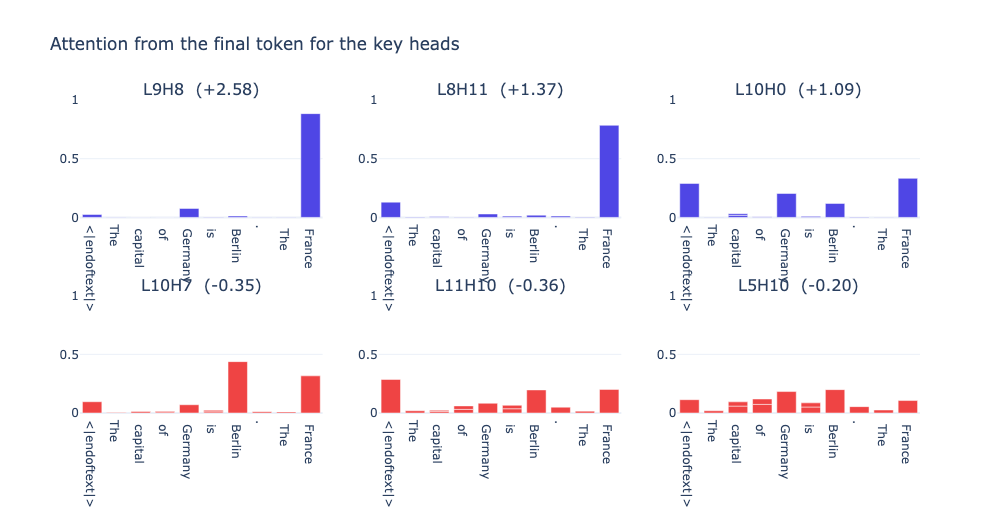

In [7]:
key_heads = [(9, 8), (8, 11), (10, 0), (10, 7), (11, 10), (5, 10)]
fig = make_subplots(rows=2, cols=3, subplot_titles=[f"L{l}H{h}  ({head_contrib[l, h]:+.2f})" for l, h in key_heads])
for i, (l, h) in enumerate(key_heads):
    fig.add_bar(x=str_toks, y=cache[f"blocks.{l}.attn.hook_pattern"][0, h, -1].cpu().numpy(),
                marker_color="#4f46e5" if head_contrib[l, h] > 0 else "#ef4444", showlegend=False,
                row=i // 3 + 1, col=i % 3 + 1)
fig.update_layout(width=1000, height=520, title="Attention from the final token for the key heads")
fig.update_yaxes(range=[0, 1]); fig.show()

In [8]:
print("what each head's actual output promotes / suppresses (LN-scaled, top-5 by logit):")
for l, h in key_heads:
    z = cache[f"blocks.{l}.attn.hook_z"][0, -1, h]
    out = (z @ model.W_O[l, h]) / cache["ln_final.hook_scale"][0, -1]
    sc = out @ model.W_U
    up = [model.to_string(i.item()) for i in sc.topk(5).indices]
    down = [model.to_string(i.item()) for i in sc.topk(5, largest=False).indices]
    print(f"  L{l}H{h} ({head_contrib[l, h]:+.2f})  promotes {up}\n             suppresses {down}")

what each head's actual output promotes / suppresses (LN-scaled, top-5 by logit):
  L9H8 (+2.58)  promotes ['French', ' France', 'France', ' Hollande', ' French']
             suppresses [' Kush', ' Boise', ' Spokane', ' Tacoma', ' Uzbek']
  L8H11 (+1.37)  promotes [' France', ' French', 'France', 'French', ' Frenchman']
             suppresses [' Kush', ' Bangalore', ' Kore', 'Pak', 'Nar']
  L10H0 (+1.09)  promotes [' Hollande', ' Macron', 'bourg', 'Paris', ' Merkel']
             suppresses [' Avatar', ' Korra', ' Kush', ' Fiji', ' Pad']
  L10H7 (-0.35)  promotes ['OSP', 'idav', 'apter', ' exerc', '�']
             suppresses ['France', ' Berlin', 'French', 'Paris', ' France']
  L11H10 (-0.36)  promotes [' Pwr', '��', ' Clown', '��', 'itary']
             suppresses ['France', ' Greenland', ' Berlin', ' Ferguson', 'panel']
  L5H10 (-0.20)  promotes [' borders', ' Governors', ' Independence', ' citiz', ' populated']
             suppresses ['duration', 'onential', 'ertodd', 'potion', 

- **L8H11** attends 78% to `" France"` and writes a narrower France/French direction. It is the first head to move country information to the answer position, one layer before L9H8.
- **L10H0** splits attention between France, Germany and Berlin and adds a further push toward French cities.
- **L10H7** attends to `" Berlin"` (44%) and `" France"` and *suppresses* France, Berlin and Paris together: it behaves like a copy-suppression head, arguing against repeating what is already salient in context. **L11H10** spreads attention over BOS, Berlin and France and does the same thing more weakly.

So the circuit is: *move the country into the final position (L8H11, L9H8), expand it into associations (L9H8's OV), reinforce (L10H0), and let a couple of late heads and the MLPs re-calibrate confidence (which is why the logit lens showed 95% at layer 9 and 70% at the output).*

## 4. Does it generalize?

If L9H8 is a country → associations head, it should do the same job for any country. For each case the counterfactual is a fixed other country's capital, so the metric stays a logit difference.

In [9]:
cases = [("France", " Paris"), ("Germany", " Berlin"), ("Japan", " Tokyo"), ("Italy", " Rome"), ("Spain", " Madrid"),
         ("China", " Beijing"), ("Egypt", " Cairo"), ("Russia", " Moscow"), ("Australia", " Canberra"), ("Canada", " Ottawa")]
rows = []
for country, capital in cases:
    demo_country, demo_capital = ("Germany", " Berlin") if country != "Germany" else ("France", " Paris")
    counter = " Rome" if capital != " Rome" else " Paris"
    p = f"The capital of {demo_country} is{demo_capital}. The capital of {country} is"
    toks = model.to_tokens(p); lg, ch = model.run_with_cache(toks)
    cid, xid = model.to_single_token(capital), model.to_single_token(counter)
    d = model.W_U[:, cid] - model.W_U[:, xid]
    hc, _ = per_head_dla(model, ch, d)
    pr = lg[0, -1].softmax(-1)
    country_pos = model.to_str_tokens(toks[0]).index(f" {country}")
    rows.append(dict(country=country, capital=capital.strip(), P=round(pr[cid].item(), 3), rank=rank_of(pr, cid),
                     logit_diff=round((lg[0, -1, cid] - lg[0, -1, xid]).item(), 2),
                     L9H8=round(hc[9, 8].item(), 2), L8H11=round(hc[8, 11].item(), 2), L10H0=round(hc[10, 0].item(), 2),
                     L9H8_attn_to_country=round(ch["blocks.9.attn.hook_pattern"][0, 8, -1, country_pos].item(), 2),
                     L9H8_share=round(hc[9, 8].item() / (lg[0, -1, cid] - lg[0, -1, xid]).item(), 2)))
df = pd.DataFrame(rows); df

,country,capital,P,rank,logit_diff,L9H8,L8H11,L10H0,L9H8_attn_to_country,L9H8_share
0,France,Paris,0.703,1,6.05,2.58,1.37,1.09,0.88,0.43
1,Germany,Berlin,0.322,1,5.84,2.57,2.08,1.09,0.94,0.44
2,Japan,Tokyo,0.767,1,9.58,3.91,3.43,1.53,0.91,0.41
3,Italy,Rome,0.617,1,6.42,2.44,1.66,1.90,0.96,0.38
4,Spain,Madrid,0.610,1,4.45,2.86,1.06,2.35,0.96,0.64
5,China,Beijing,0.559,1,8.60,5.16,2.64,1.47,0.94,0.60
6,Egypt,Cairo,0.890,1,5.88,3.74,2.15,3.71,0.94,0.64
7,Russia,Moscow,0.596,1,8.45,5.19,1.99,3.07,0.96,0.61
8,Australia,Canberra,0.155,3,5.67,4.83,1.53,1.38,0.97,0.85
9,Canada,Ottawa,0.132,3,7.71,5.24,1.80,1.33,0.96,0.68


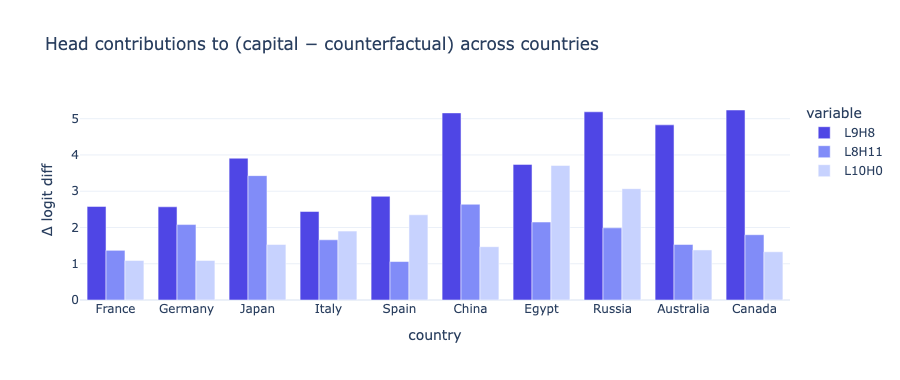

L9H8 attends to the country token with mean weight 0.94 and supplies 57% of the logit difference on average (range 38%–85%).
the model gets the capital at rank 1 for 8/10 countries.


In [10]:
fig = px.bar(df, x="country", y=["L9H8", "L8H11", "L10H0"], barmode="group", title="Head contributions to (capital − counterfactual) across countries",
             color_discrete_sequence=["#4f46e5", "#818cf8", "#c7d2fe"])
fig.update_layout(width=900, height=380, yaxis_title="Δ logit diff"); fig.show()
print(f"L9H8 attends to the country token with mean weight {df.L9H8_attn_to_country.mean():.2f} and supplies "
      f"{df.L9H8_share.mean():.0%} of the logit difference on average (range {df.L9H8_share.min():.0%}–{df.L9H8_share.max():.0%}).")
print(f"the model gets the capital at rank 1 for {(df['rank'] == 1).sum()}/{len(df)} countries.")

The same three heads carry every country, with L9H8 always the largest, attending 88–97% to the country token every time. The two misses are instructive. For Australia the model says " Sydney" (35%) over " Canberra" (16%), yet L9H8 is doing its job: its OV bundle for Australia ranks " Canberra" 4th and " Sydney" 8th, and its contribution to Canberra-over-Rome is one of the largest in the table. The error comes from the rest of the network, which adds a "big Australian city" prior that L9H8's vote cannot overcome. The routing circuit is general and reusable; the *knowledge* is distributed and sometimes wrong in ways the circuit does not control.

## 5. The whole computation in one picture

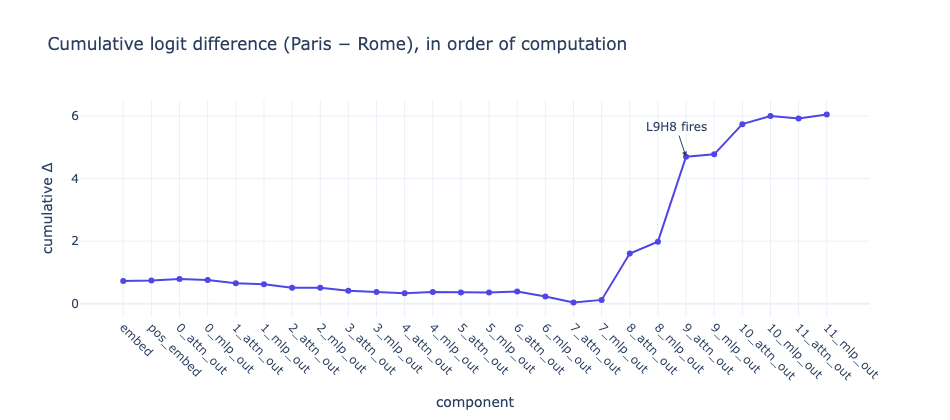

In [11]:
cum = np.cumsum(layer_contrib.numpy()) + bias_term
fig = go.Figure()
fig.add_scatter(x=layer_labels, y=cum, mode="lines+markers", marker_color="#4f46e5")
fig.add_annotation(x="9_attn_out", y=cum[layer_labels.index("9_attn_out")], text="L9H8 fires", showarrow=True, arrowhead=2)
fig.update_layout(width=950, height=420, title="Cumulative logit difference (Paris − Rome), in order of computation",
                  xaxis_title="component", yaxis_title="cumulative Δ", xaxis_tickangle=45)
fig.show()

## 6. What we learned

**The circuit.** Country identity is moved from the `" France"` position to the answer position by two heads (L8H11, then L9H8). L9H8's OV circuit expands the country into a bundle of associated tokens; the city-shaped part of that bundle is what the final position reads out. L10H0 reinforces; L10H7 and L11H10 (copy-suppression-like heads watching `" Berlin"`) and the late MLPs bring the probability from 95% down to a calibrated 70%.

**The method.** Direct logit attribution is only trustworthy when the accounting closes. Use a logit difference against a named counterfactual, push components through the cached final-LayerNorm scale, and check that the terms plus the unembed bias reproduce the observed number. If they do not, the numbers mean nothing.

**Its limit.** DLA only sees the *direct* path from a component to the logits. L8H11's real job is probably to feed L9H8, and none of that shows up here. To see indirect effects you have to intervene: **Phase 3, activation patching.**

In [12]:
def trace(prompt, correct, counterfactual, top=6):
    toks = model.to_tokens(prompt); lg, ch = model.run_with_cache(toks)
    a, b = model.to_single_token(correct), model.to_single_token(counterfactual)
    hc, _ = per_head_dla(model, ch, model.W_U[:, a] - model.W_U[:, b])
    print(f"{prompt!r}: logit diff {correct!r} − {counterfactual!r} = {(lg[0,-1,a]-lg[0,-1,b]).item():+.2f}")
    for n, v in sorted([(f"L{l}H{h}", hc[l, h].item()) for l in range(12) for h in range(12)], key=lambda x: -abs(x[1]))[:top]:
        print(f"   {n:7s} {v:+.2f}")

trace("The Eiffel Tower is in the city of", " Paris", " London")
trace("Q: What language do they speak in France?\nA:", " French", " German")

'The Eiffel Tower is in the city of': logit diff ' Paris' − ' London' = -0.16
   L1H10   +0.19
   L9H8    -0.18
   L2H5    -0.14
   L0H9    +0.13
   L5H7    -0.13
   L11H10  +0.12
'Q: What language do they speak in France?\nA:': logit diff ' French' − ' German' = +4.68
   L9H8    +1.29
   L11H2   +1.02
   L10H0   +0.96
   L11H10  -0.81
   L10H10  +0.74
   L10H7   -0.59
